# Phishing link classifier

For the phishing URL-data I will be using https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset -dataset, that includes 134,850 legitimate and 100,945 phishing URLs

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 

phiusiil_phishing_url_website = fetch_ucirepo(id=967)

The dataset includes URL:s and their features in `phiusiil_phishing_url_website.data.features` and labels (phishing or not phishing) in `y = phiusiil_phishing_url_website.data.targets`.

In [3]:
X = phiusiil_phishing_url_website.data.features
X.tail()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
235790,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,0.058739,...,0,1,0,1,51,7,21,187,2,191
235791,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,0.053834,...,0,1,0,0,50,1,7,88,0,31
235792,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,0.063093,...,0,0,0,1,27,10,30,58,2,67
235793,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,0.050211,...,0,0,0,0,0,0,3,0,0,0
235794,https://www.alternativefinland.com,33,www.alternativefinland.com,26,0,com,100.000000,1.000000,0.522907,0.060596,...,0,0,0,1,21,6,18,256,0,261


In [4]:
y = phiusiil_phishing_url_website.data.targets
y.tail()

,label
235790,1
235791,1
235792,1
235793,0
235794,1


I'm only interested in URL:s and labels for now, so I will create a new dataframe that includes only these. Later I will make my own features from URL:s

In [5]:
# Combine dataframes
df = pd.concat([phiusiil_phishing_url_website.data.features, phiusiil_phishing_url_website.data.targets], axis=1)
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [6]:
# Drop all but URL and label and rename label
df = df[["URL", "label"]]

df = df.rename(columns={"label" : "isLegit"})

df.head()

,URL,isLegit
0,https://www.southbankmosaics.com,1
1,https://www.uni-mainz.de,1
2,https://www.voicefmradio.co.uk,1
3,https://www.sfnmjournal.com,1
4,https://www.rewildingargentina.org,1


In [7]:
# Check that there is no null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   URL      235795 non-null  str  
 1   isLegit  235795 non-null  int64
dtypes: int64(1), str(1)
memory usage: 3.6 MB


## Extracting URL features

I wrote a python scipt [/src/features.py](/src/features.py) that grabs some basic features from the URL:s. These features include `is_HTTPS`, `is_IP`, `host_length`, `number_count`, `dot_count`, `hyphen_count`, `path_depth`, `has_params` and `enthropy`.

Features explained:
* `is_HTTPS` returns 1 if link uses HTTPS and 0 if link uses HTTP.
* `is_IP` returns 1 if link uses IP address and 0 if link uses domain names.
* `host_length` returns the length of hostname.
* `number_count` returns the number of numbers in hostname.
* `dot_count` returns the number of dots in hostname.
* `hyphen_count` returns the number of hyphens ("-") in hostname.
* `path_depth` returns the number of slashes ("/") in path.
* `has_params` returns 1 if link has parameters and 0 if not.
* `entropy` returns the shannon entropy of the hostname. Shannon entropy calculates how random the characters in hostname are from 0 to 5.

Next import all the features from URL:s into a new dataframe.

In [8]:
# features.py is in /src so I need to add it to pythons path
import sys
sys.path.insert(0, "../src")

In [9]:
import importlib                                                                                                                                                             
import features 
importlib.reload(features)

<module 'features' from '/Users/lassihirvonen/git/Phishing-link-classifier/notebook/../src/features.py'>

In [10]:
# extract features into a datarframe
details = [features.extract_features(url) for url in df["URL"]]
df_features = pd.DataFrame(details)
df_features.shape

(235795, 9)

In [11]:
df_features.head()

,is_HTTPS,is_IP,host_length,number_count,dot_count,hyphen_count,path_depth,has_params,entropy
0,1,0,24,0,2,0,0,0,3.657268
1,1,0,16,0,2,1,0,0,3.327820
2,1,0,22,0,3,0,0,0,3.629220
3,1,0,19,0,2,0,0,0,3.576618
4,1,0,26,0,2,0,0,0,3.430457


Now let's add features to original dataframe

In [12]:
df = pd.concat([df, df_features], axis=1)

In [13]:
df.head()

,URL,isLegit,is_HTTPS,is_IP,host_length,number_count,dot_count,hyphen_count,path_depth,has_params,entropy
0,https://www.southbankmosaics.com,1,1,0,24,0,2,0,0,0,3.657268
1,https://www.uni-mainz.de,1,1,0,16,0,2,1,0,0,3.327820
2,https://www.voicefmradio.co.uk,1,1,0,22,0,3,0,0,0,3.629220
3,https://www.sfnmjournal.com,1,1,0,19,0,2,0,0,0,3.576618
4,https://www.rewildingargentina.org,1,1,0,26,0,2,0,0,0,3.430457


## Analyzing dataframe

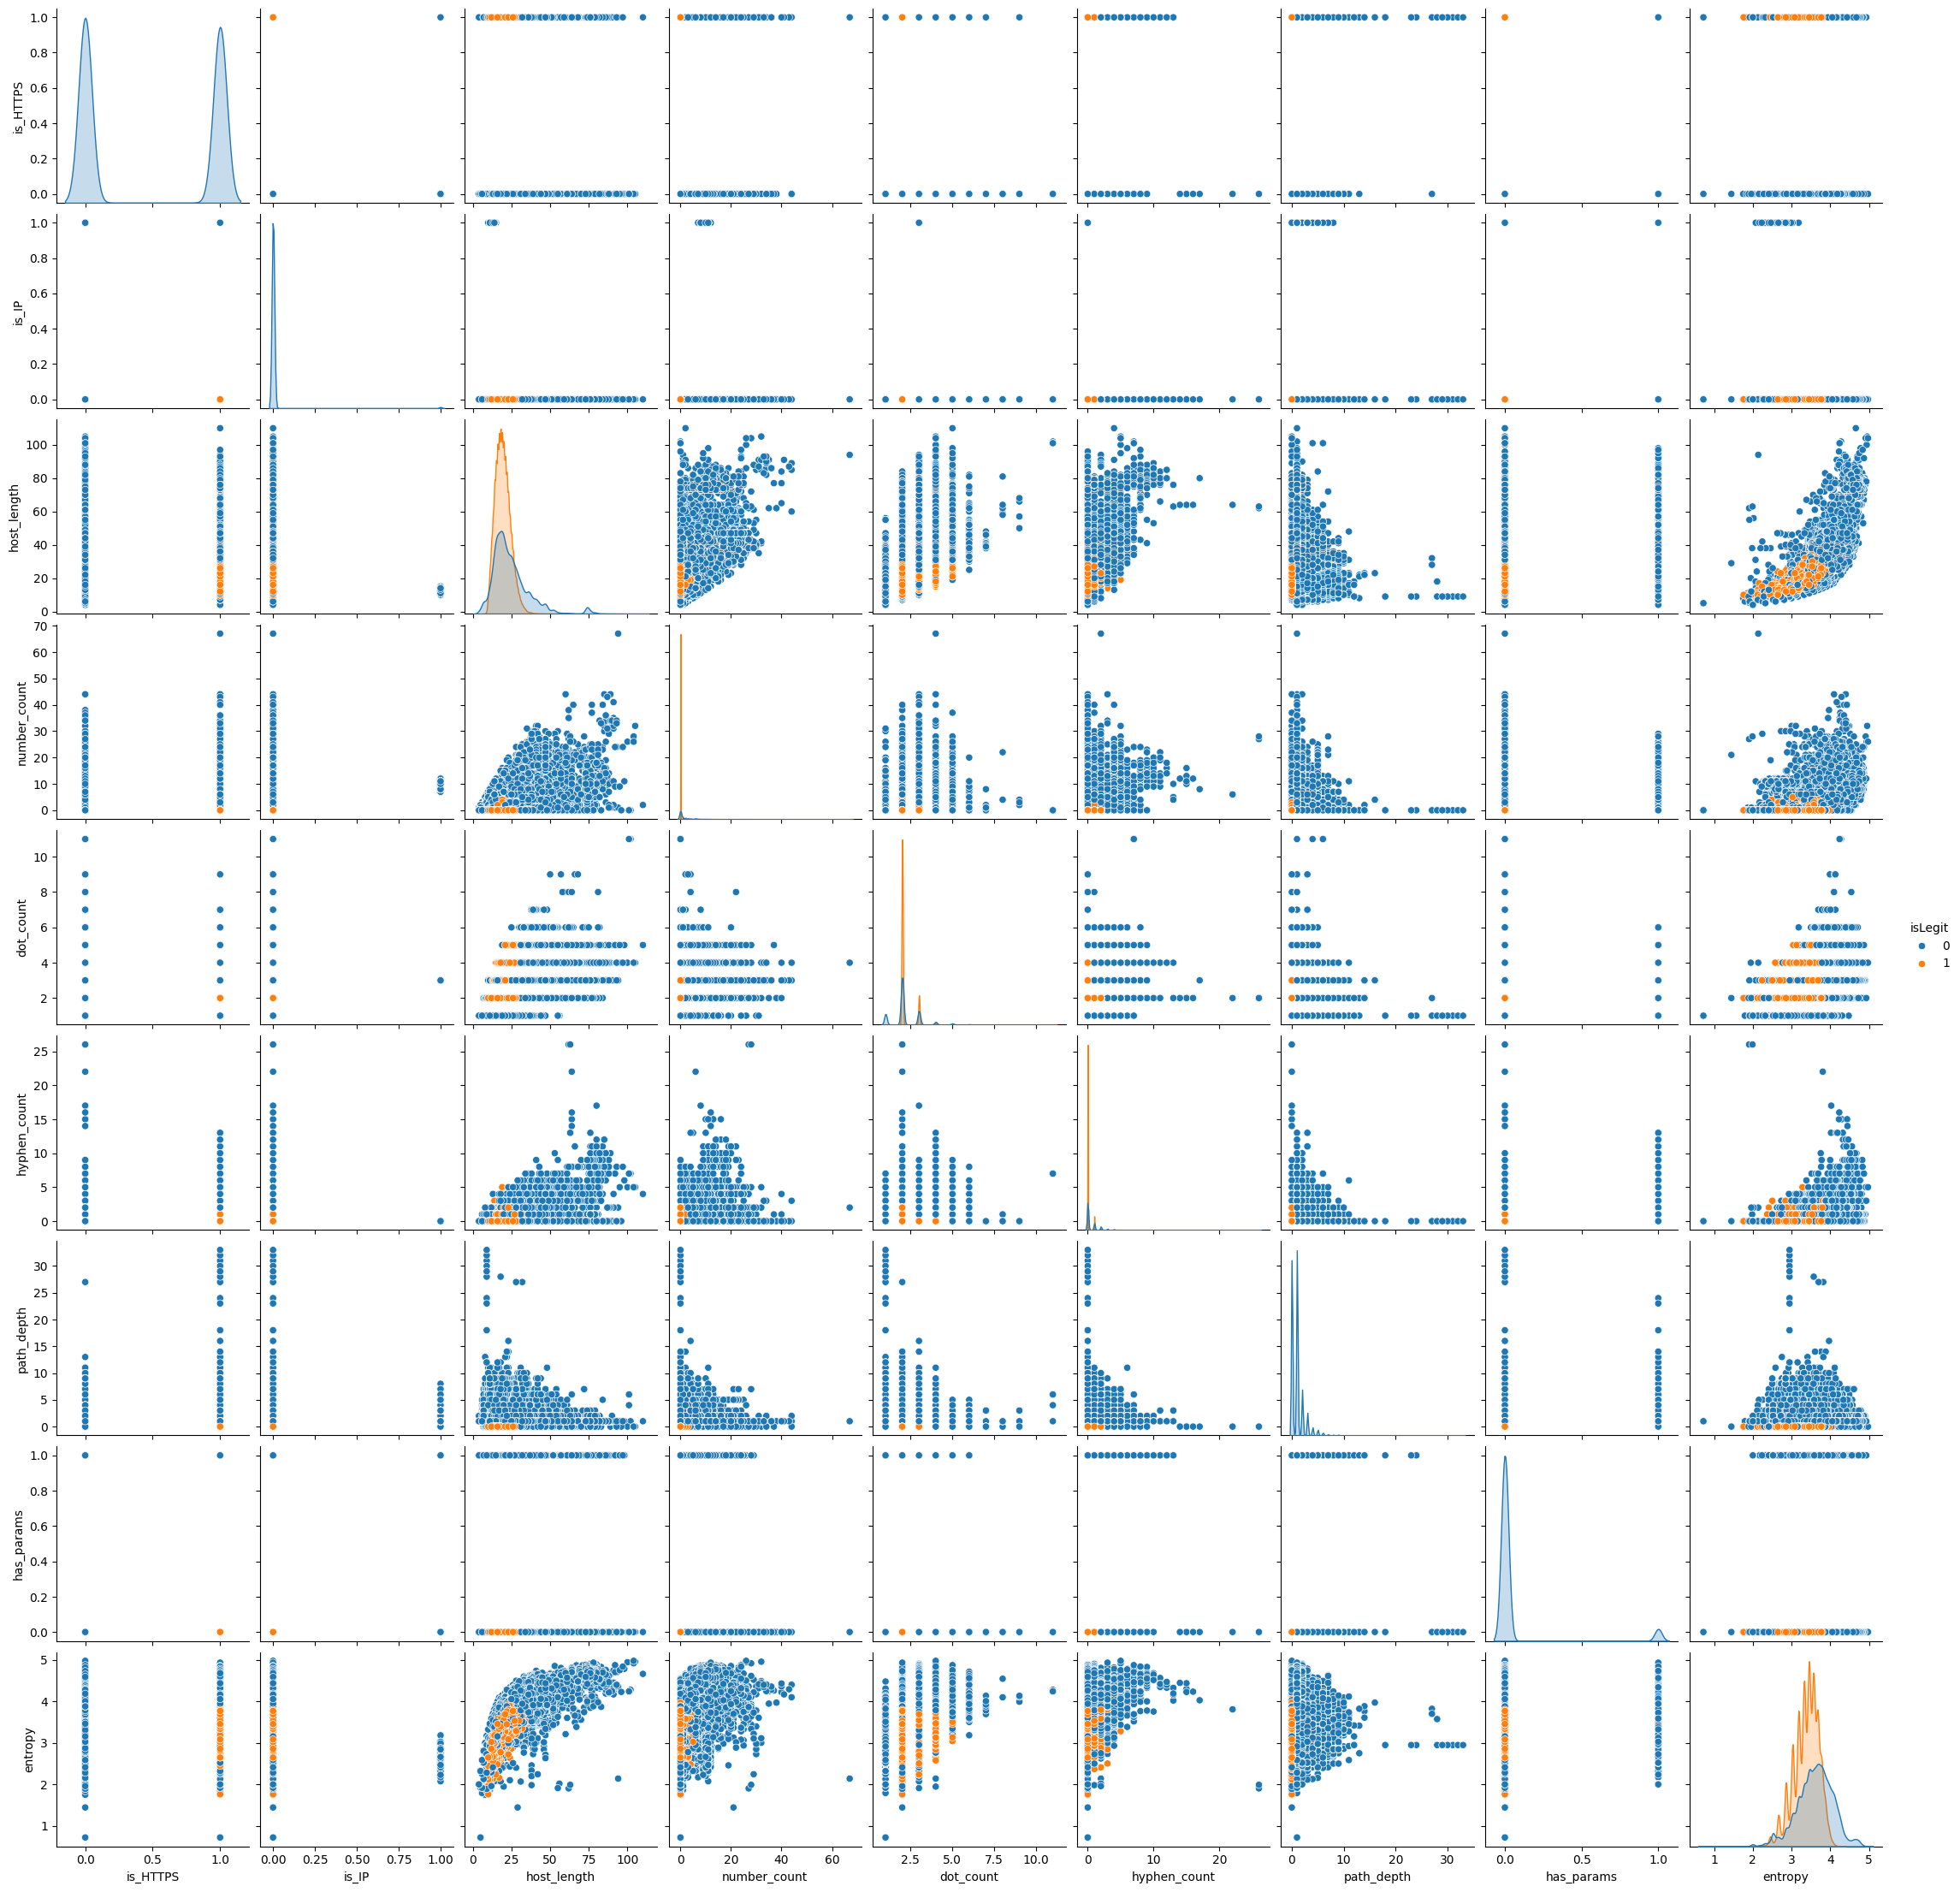

In [ ]:
# scatterplot
import seaborn as sns

sns.pairplot(df, kind="scatter", hue="isLegit")

The orange dots represent safe URL:s and blue dots represent phishing URL:s. From the scatterplot we can see that there is a lot more phishing URL:s than legit URL:s. Also phishng links tend to be more evenly distributed across the features. For example all the legit links have path depth around 0, but phishing links spread from 0 to 30. The same pattern can be seen in other plots (like has_params) as well.

This is not desirable and might cause models to classify all links that have path longer than 1 as malicious.

## Splitting to training and testing data

In [18]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=["isLegit", "URL"])
y = df["isLegit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=55, train_size=0.8)

print(X_train.shape, X_test.shape)

(188636, 9) (47159, 9)


## Training models

First lets train decision tree.

In [20]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(max_depth=5, random_state=2).fit(X_train, y_train)

Now it's accuracy.

In [21]:
print(f"Training data: {model_tree.score(X_train, y_train)}")
print(f"Testing data: {model_tree.score(X_test, y_test)}")

Training data: 0.9948737250577833
Testing data: 0.9944019169193579


For both training and testing data the model seems very accurate.

Now lets train Random forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(max_depth=None, random_state=2).fit(X_train, y_train)

Lets see it's accuracy

In [23]:
print(f"Training data: {model_forest.score(X_train, y_train)}")
print(f"Testing data: {model_forest.score(X_test, y_test)}")

Training data: 0.9972221633198329
Testing data: 0.9948684238427448


Also very accurate.

Lastly I will train Gradient boosting.

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

model_gb = gb.fit(X_train, y_train)

In [26]:
print(f"Training data: {model_gb.score(X_train, y_train)}")
print(f"Testing data: {model_gb.score(X_test, y_test)}")

Training data: 0.9954356538518628
Testing data: 0.9952077016052079


Out of the tree model gradient boosting seems to be the best.

## Benchmark models with confusion matrix

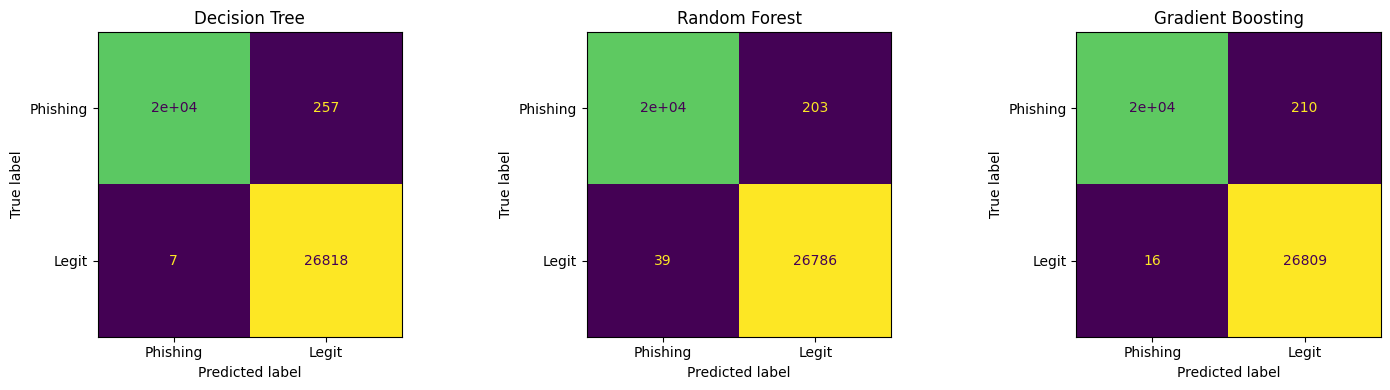

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = [
    ("Decision Tree", model_tree),
    ("Random Forest", model_forest),
    ("Gradient Boosting", model_gb),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Phishing", "Legit"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

Confusion matrixes for the models.

Decision tree:
* Most false negatives but least false positives
* Good for detecting if a link is legit, bad for detecting if a link is phishing

Random forest:
* Least false negatives but most false positives
* Good for detecting if a link is phishing, bad for detecting if a link is legit

Gradient boosting:
* Middle ground between decision tree and random forest
* Decent at detecting phishing and legit links

For the purpose of a phishing link detector I think that random forest is the best since it is best at detecting if a link is malicious. As the saying goes "it is better to be safe than sorry".

## Testing models with custom links

In [41]:
custom_urls = [
    "https://www.google.com",
    "http://192.168.1.1/login?user=admin",
    "https://paypal-secure-login.xyz/verify",
    "https://lassihirvonen.com/palvelinten_hallinta/",
    "https://m1crosoft.com"
]

df_custom = pd.DataFrame({"URL": custom_urls})
df_custom = pd.concat(
    [df_custom, pd.DataFrame([features.extract_features(url) for url in custom_urls])],
    axis=1,
)

X_custom = df_custom.drop(columns=["URL"])

print(f"Decision tree: {model_tree.predict(X_custom)}")
print(f"Random forest: {model_forest.predict(X_custom)}")
print(f"Gradient boosting: {model_gb.predict(X_custom)}")

Decision tree: [1 0 0 0 0]
Random forest: [1 0 0 0 0]
Gradient boosting: [1 0 0 0 0]


All of the models gave the same results. www.google.com was labeled legit and others were labeled as phishing. As I earlier suspected, the models seem to label url:s with long paths as phishing like "lassihirvonen.com/palvelinten_hallinta/".

## Demonstrating decision tree

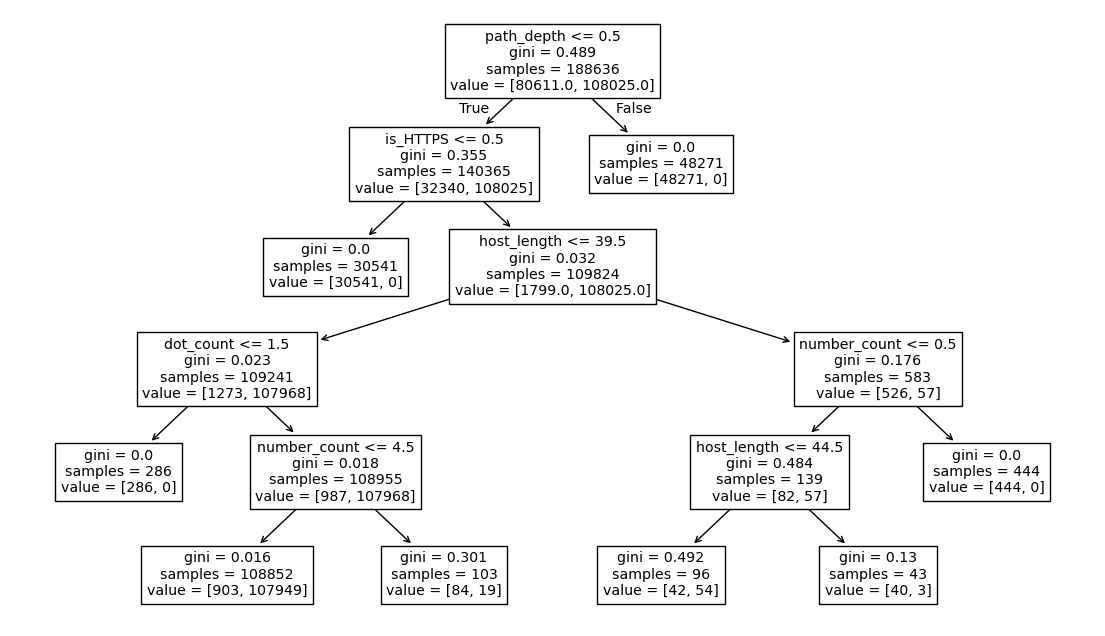

In [36]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(decision_tree=model_tree, feature_names=X.columns)
plt.show()

From the tree we can see that first is checked the number of paths. If there is a path the URL is labeled immediately as phishing. This is a really big weakness that is caused by the used dataset. The best fix would maybe be training with a new dataset.

If there is no path then next is checked if the URL uses HTTPS. If the URL uses HTTP it is immediately determined as phishing. This is a second big weakness in the model which is also caused by the dataset lacking legit URL:s using HTTP.

If the link uses HTTPS next is checked hostname length. If it is less than 39.5 then is checked dot count. If it has less than 2 dots it is labeled phishing. This means that "https://google.com" is malicious. If the hostname is longer than 39,5 characters and has any numbers it is labeled as phishing.

## Exporting current models

In [ ]:
import joblib

joblib.dump(model_tree, "../models/PhiUSIIL_model_tree.pkl")
joblib.dump(model_forest, "../models/PhiUSIIL_model_forest.pkl")
joblib.dump(model_gb, "../models/PhiUSIIL_model_gb.pkl")

['../models/model_gb.pkl']

## 